In [17]:
from bs4 import BeautifulSoup
import requests
import pandas as pd
import time
import random
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

In [19]:
#making connection
import requests

session = requests.Session()
session.headers.update({
    "User-Agent": "Mozilla/5.0",
    "X-Requested-With": "XMLHttpRequest"
})

# url for loading homepage
session.get("https://trend.sec.kerala.gov.in/")

<Response [200]>

In [21]:
#creating code corresponding Gramma panchayath,Block,district,corporation
govt_codes = ["P", "B", "D", "C"]
print(govt_codes)
district_codes = [f"D{str(i).zfill(2)}001" for i in range(1, 15)]
print(district_codes)

['P', 'B', 'D', 'C']
['D01001', 'D02001', 'D03001', 'D04001', 'D05001', 'D06001', 'D07001', 'D08001', 'D09001', 'D10001', 'D11001', 'D12001', 'D13001', 'D14001']


In [23]:
#getting data through api for p,b,d,c
api_url = "https://trend.sec.kerala.gov.in/includes/stateView2_ajax.php"

results_district = {}

for g_code in tqdm(govt_codes, desc="Downloading district level wards", unit="gov"):
    results_district[g_code] = {}

    for d_code in district_codes:
        payload = {
            "_p": "dv",
            "_l": g_code,
            "_d": d_code,
            "_s": "L"
        }

        try:
            response = session.post(api_url, data=payload, timeout=30)
            response.raise_for_status()
            results_district[g_code][d_code] = response.json()


        except Exception as e:
            tqdm.write(f"Failed: gov={g_code}, dist={d_code}, error={e}")

In [24]:
columns = [
    "WardCode",
    "WardName",
    "NumSeats",
    "Majority",
    "UDF",
    "LDF",
    "NDA",
    "OTH",
    "Status"
]

rows = []

for g_code, districts in results_district.items():
    for d_code, lb_data in districts.items():

        payload = lb_data.get("payload", [])

        for record in payload:
            row = dict(zip(columns, record))
            row["GovCode"] = g_code
            row["DistrictCode"] = d_code
            rows.append(row)

df = pd.DataFrame(rows)

df.to_csv("vote_details.csv", index=False, encoding="utf-8-sig")

In [25]:
#getting data through api for ward
api_url = "https://trend.sec.kerala.gov.in/includes/lb_ajax2.php"
results_ward = {}

codes = df.WardCode.dropna().tolist()

for val in tqdm(codes, desc="Downloading wards", unit="Units"):
    payload = {
        "_p": "wv",
        "_w": val,
        "_t": "P",
        "_s": "L"
    }

    try:
        response = session.post(api_url, data=payload, timeout=30)
        response.raise_for_status()
        results_ward[val] = response.json()


    except Exception as e:
        tqdm.write(f"Failed_{val}: {e}")

In [29]:
columns = [
    "WardCode",
    "Party",
    "Candidate_code_first",
    "CandidateName_first",
    "Votes_first",
    "WardName",
    "Status",
    "Candidate_code_first",
    "CandidateName_second",
    "Votes_second"
]

rows = []

for lb_code, lb_data in results_ward.items():
    payload = lb_data.get("payload", [])

    for record in payload:
        row = dict(zip(columns, record))
        row["LB_Code"] = lb_code
        rows.append(row)

df = pd.DataFrame(rows)
df.to_csv("vote_details.csv", index=False, encoding="utf-8-sig")


Top Parties:

  Party  Votes_first  VoteShare_%
3   UDF     14766874    54.229528
0   LDF     10393366    38.168358
1   NDA      1111234     4.080870
2   OTH       958846     3.521244


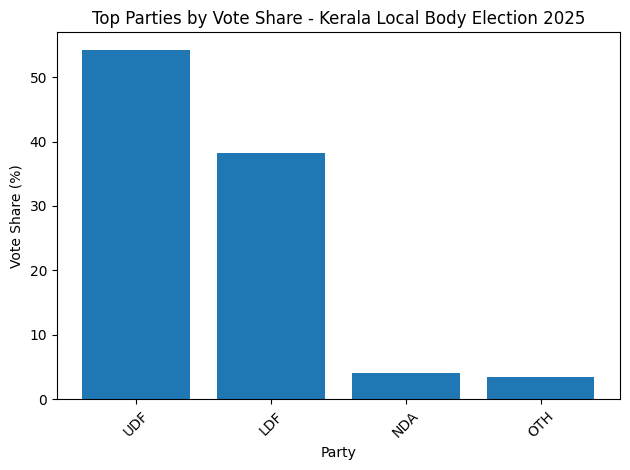

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

#loading csv
df = pd.read_csv("vote_details.csv")

#cleaning
df["Votes_first"] = pd.to_numeric(df["Votes_first"], errors="coerce")
df = df.dropna(subset=["Votes_first", "Party"])

party_votes = df.groupby("Party")["Votes_first"].sum().reset_index()

# calculating voteshares%
total_votes = party_votes["Votes_first"].sum()

party_votes["VoteShare_%"] = (party_votes["Votes_first"] / total_votes) * 100

#top parties
top = party_votes.sort_values(by="Votes_first", ascending=False).head(5)

print("\nTop Parties:\n")
print(top)

#charts
plt.figure()

plt.bar(top["Party"], top["VoteShare_%"])

plt.xlabel("Party")
plt.ylabel("Vote Share (%)")
plt.title("Top Parties by Vote Share - Kerala Local Body Election 2025")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()